# NHS Workforce Hierarchical Forecast
This notebook demonstrates:

- Data aggregation & filtering

- Hierarchy setup

- Naive forecasting and hierarchical reconciliation

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.evaluation import evaluate
from hierarchicalforecast.methods import BottomUp, MinTrace
from hierarchicalforecast.utils import aggregate
from statsforecast import StatsForecast
from statsforecast.models import Naive

## 1. 🚚 Data Load and Preprocessing

- Data is imported from your main, deduplicated monthly NHS workforce dataset.
- Columns are lowercased and whitespace-trimmed for consistent grouping and joining.
- Only groups with ≥24 months are retained, ensuring robust forecasting and reconciliation.


In [2]:
base_dir = r"C:\Users\Destinee.HassanBien\Documents\Desys Work"
all_agg_file = os.path.join(base_dir, "combined_workforce_monthly_new.csv")
all_agg = pd.read_csv(all_agg_file, parse_dates=["month"])
all_agg.columns = all_agg.columns.str.lower().str.strip()

In [3]:
# Filter groups with at least 24 rows to avoid sparse series
group_cols = ["service group", "staff group", "metric"]
count = all_agg.groupby(group_cols).size()
valid_groups = set(count[count >= 24].index)
all_agg_hier = all_agg.set_index(group_cols)
all_agg_hier = all_agg_hier.iloc[all_agg_hier.index.isin(valid_groups)].reset_index()

## 2. 🏗️ Build Hierarchy Structure

Why Build Hierarchy?
- Ensures forecasts "add up" the same way Trust reports roll up: NHS → service → staff group → metric.
- Prevents inconsistencies at sub/aggregate levels in reporting.

In [4]:
all_agg_hier["Total"] = "NHS"
spec = [
    ["Total"],
    ["Total", "service group"],
    ["Total", "service group", "staff group"],
    ["Total", "service group", "staff group", "metric"],
]
ys = all_agg_hier.rename(
    columns={
        "month": "ds",
        "count": "y",
        "service group": "service group",
        "staff group": "staff group",
        "metric": "metric",
    }
)

Y_df, S_df, tags = aggregate(ys, spec)
Y_df = Y_df.sort_values(["unique_id", "ds"])

## 3. 🕒 Set Forecast Horizon: Through March 2027

- The forecast extends to March 2027 so NHS teams can plan for the entire next financial year (or longer).
- The code calculates the number of months from the last actual to this target date.

In [5]:
# Find last observed date
observed_last = Y_df["ds"].max()
# Target horizon: from (observed_last + 1 month) up to March 2027
forecast_until = pd.Timestamp("2027-03-01")
n_months_forward = (forecast_until.year - observed_last.year) * 12 + (
    forecast_until.month - observed_last.month
)
horizon = max(n_months_forward, 12)

## 4. 🔮 Forecasting and Hierarchical Reconciliation
- Naive forecast is used as the core (baseline) model.
- BottomUp and MinT (MinTrace-OLS, MinT-shrink) provide sum consistent hierarchical forecasts, which are essential for comprehensive reporting.

In [6]:
sf = StatsForecast(models=[Naive()], freq="MS", n_jobs=-1)
# Use ALL available data for most up to date forecast
Y_hat_df = sf.forecast(h=horizon, df=Y_df, fitted=True)
Y_fitted_df = sf.forecast_fitted_values()

In [7]:
reconcilers = [BottomUp(), MinTrace(method="ols"), MinTrace("mint_shrink")]
hrec = HierarchicalReconciliation(reconcilers=reconcilers)
Y_rec_df = hrec.reconcile(Y_hat_df=Y_hat_df, Y_df=Y_fitted_df, S=S_df, tags=tags)

## 5. 🔧 Deduplicate Observed Data for Tidy Output
Interpretation
- Aggregating observed data by unique_id and date avoids duplicates in the plots/table.
- The result is a clean time series per group, ready for merging with model forecast outputs.

In [8]:
# Group by unique_id and ds, use mean for multiple records per period
obs_df = (
    Y_df[["unique_id", "ds", "y"]]
    .groupby(["unique_id", "ds"], as_index=False)
    .mean()
    .rename(columns={"y": "observed"})
)

## 6. 🎯 Choose A Valid Group & Merge for Plotting
- Always use a group (unique_id) found in both the observed and reconciled forecast tables.
- If a plot is blank or NaNs appear, check for typos or choose another group from the provided options.


In [9]:
uids_obs = set(obs_df['unique_id'].unique())
uids_fc = set(Y_rec_df['unique_id'].unique())
valid_uids = uids_obs & uids_fc

In [10]:
# Change to any group desired, such as:
uid = "NHS/Medical Services/Administrative and Clerical/Leavers"

# Observed history
obs_df = (
    Y_df[Y_df["unique_id"] == uid][["ds", "y"]]
    .rename(columns={"y": "observed"})
    .sort_values("ds")
)

# Forecast for future
fc_cols = [
    "Naive",
    "Naive/BottomUp",
    "Naive/MinTrace_method-ols",
    "Naive/MinTrace_method-mint_shrink",
]
fc_df = Y_rec_df[Y_rec_df["unique_id"] == uid][["ds"] + fc_cols].sort_values("ds")

merged = pd.merge(obs_df, fc_df, on="ds", how="outer").sort_values("ds")

## 7. 📊 Plot Hierarchical Forecasts

- **Black line:** Historical reality (actuals/observed)
- **Colored lines:** Naive and sum consistent forecasts for each future month.
- **If all forecast lines are flat:** The group is stable Naive forecast is usually optimal and governance-safe to report.
- The plot is suited to Power BI/management dashboards and Trust-level reviews.

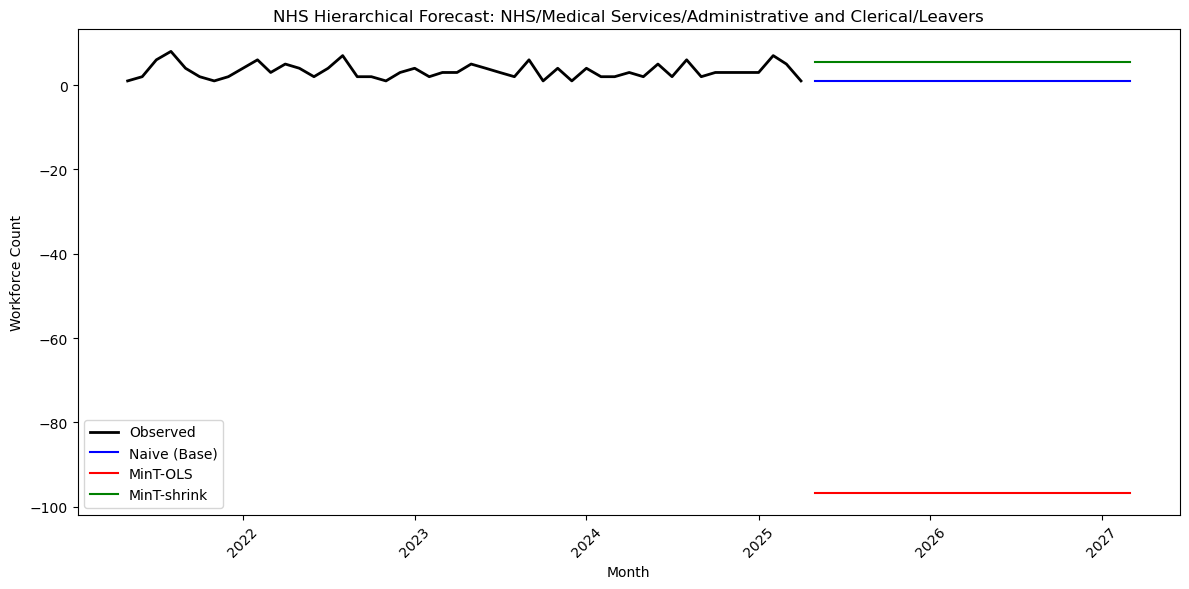

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(merged["ds"], merged["observed"], label="Observed", color="black", linewidth=2)
plt.plot(merged["ds"], merged["Naive"], label="Naive (Base)", color="blue")
plt.plot(
    merged["ds"], merged["Naive/MinTrace_method-ols"], label="MinT-OLS", color="red"
)
plt.plot(
    merged["ds"],
    merged["Naive/MinTrace_method-mint_shrink"],
    label="MinT-shrink",
    color="green",
)

plt.xlabel("Month")
plt.ylabel("Workforce Count")
plt.title(f"NHS Hierarchical Forecast: {uid}")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

## ✅ Key Points for NHS Dashboards & Review
- **Observed history** shows real workforce changes -> use to gauge trust/model credibility.
- **Forecasts** (Naive and reconciled): Advised as best in class for operational plans, scenario testing, and staffing dashboards.
- **Methodology**: Hierarchical modeling ensures outputs are consistent from Trust total down to granular units by staff/metric.